In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as T
from torchvision import models
import matplotlib.pyplot as plt
import copy
import numpy as np
import seaborn as sns
from tqdm import tqdm
from pathlib import Path
from torch.utils.data import DataLoader, WeightedRandomSampler
from PIL import Image
from sklearn.metrics import confusion_matrix
from collections import Counter
from sklearn.metrics import cohen_kappa_score
from torchvision.transforms import InterpolationMode

In [2]:
transform_train = T.Compose([
    T.Resize((380, 380), interpolation=InterpolationMode.BICUBIC),
    T.RandomRotation(degrees=15),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.02),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_val = T.Compose([
    T.Resize((380, 380)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [3]:
train_dataset = torchvision.datasets.ImageFolder(
    root="../dataset/Dataset_Diabetic_Retinopathy_Detection_labeled/train",
    transform=transform_train
)

val_dataset = torchvision.datasets.ImageFolder(
    root="../dataset/Dataset_Diabetic_Retinopathy_Detection_labeled/val",
    transform=transform_val
)

In [4]:
batch_size = 16

count_images = torch.tensor([20648, 1954, 4234, 698, 566], dtype=torch.float32)
class_weights = 1.0 / torch.sqrt(count_images)

sample_weights = [class_weights[label] for label in train_dataset.targets]

sample = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

trainloader = DataLoader(train_dataset, 
                         batch_size=batch_size, 
                         sampler=sample, 
                         pin_memory=True,
                         num_workers=4,
                         persistent_workers=True,
                         drop_last=True)

valloader = DataLoader(val_dataset,
                       batch_size=batch_size * 2,
                       shuffle=False,
                       pin_memory=True,
                       num_workers=4,
                       persistent_workers=True)

In [5]:
train_dataset.class_to_idx

{'0': 0, '1': 1, '2': 2, '3': 3, '4': 4}

In [ ]:
counts_train = Counter(train_dataset.targets)

for idx, count in counts_train.items():
    print(f"Class {train_dataset.classes[idx]}: {count} images")

Class 0: 20648 images
Class 1: 1954 images
Class 2: 4234 images
Class 3: 698 images
Class 4: 566 images


In [5]:
counts_val = Counter(val_dataset.targets)

for idx, count in counts_val.items():
    print(f"class {val_dataset.classes[idx]}: {count} images")

class 0: 5162 images
class 1: 489 images
class 2: 1058 images
class 3: 175 images
class 4: 142 images


In [5]:
class DRD_EfficientNetB4(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()

        self.backbone = models.efficientnet_b4(weights="DEFAULT")

        in_features = self.backbone.classifier[-1].in_features

        self.backbone.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

   
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DRD_EfficientNetB4().to(device)

for param in model.backbone.features.parameters():
    param.requires_grad = False

optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-3)

loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-6)

In [8]:
if device.type == "cuda":
    print("Training with CUDA")
else:
    print("Training with CPU")

Training with CUDA


In [ ]:
def qwk(y_true, y_pred):
    return cohen_kappa_score(y_true, y_pred, weights='quadratic')

n_epoch = 200

best_qwk = -1
best_weights = None
best_epoch = -1

train_loss_hist = []
train_acc_hist = []
val_loss_hist = []
val_acc_hist = []
qwk_hist = []

early_stopping = 25

for epoch in range(n_epoch):

    if epoch == 5:
        print("Unfreezing backbone...")

        for param in model.backbone.features.parameters():
            param.requires_grad = True

        optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5, weight_decay=1e-3)

        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100, eta_min=1e-7)

    epoch_loss = []
    epoch_acc = []

    model.train()
    with tqdm(trainloader, unit="batch") as bar:
        bar.set_description(f"Epoch {epoch}")
        for X_batch, y_batch in bar:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            acc = (torch.argmax(y_pred, 1) == y_batch).float().mean().item()
            epoch_loss.append(loss.item())
            epoch_acc.append(acc)

            bar.set_postfix(loss = loss.item(), acc = acc)

        train_acc_hist.append(np.mean(epoch_acc))
        train_loss_hist.append(np.mean(epoch_loss))
    
    model.eval()

    val_loss = []
    val_acc = []

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in valloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            y_pred = model(X_batch)
            preds = (torch.argmax(y_pred, 1))
            loss = loss_fn(y_pred, y_batch)
            acc = (preds == y_batch).float().mean().item()

            val_loss.append(loss.item())
            val_acc.append(acc)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    ce = np.mean(val_loss)
    acc = np.mean(val_acc)
    qwk_score = qwk(all_labels, all_preds)
    scheduler.step()
    val_loss_hist.append(ce)
    val_acc_hist.append(acc)
    qwk_hist.append(qwk_score)
    
    if qwk_score > best_qwk:
        best_qwk = qwk_score
        best_epoch = epoch
        best_weights = copy.deepcopy(model.state_dict())
        print(f"✅ Best QWK with value {best_qwk:.4f} in the epoch {best_epoch}")

    if epoch > 30 :
        if epoch - best_epoch > early_stopping:
            print(f"Early stopping activated in epoch {epoch}. The best QWK was in the {best_epoch}")
            break

    print(f"Epoch {epoch} validation: Loss = {ce:.2f}, Acc= {acc * 100:.2f}%, QWK = {qwk_score:.2f}")

if best_weights is not None:
    model.load_state_dict(best_weights)

save_path = Path("../model/retinopathy_model_B4.pth")

torch.save(model.state_dict(), save_path)

print(f"✅ Best model saved with QWK {best_qwk:.4f}")

Epoch 0: 100%|██████████| 1756/1756 [03:29<00:00,  8.37batch/s, acc=0.5, loss=1.23]   


✅ Best QWK with value 0.3245 in the epoch 0
Epoch 0 validation: Loss = 1.04, Acc= 72.98%, QWK = 0.32


Epoch 1: 100%|██████████| 1756/1756 [03:21<00:00,  8.70batch/s, acc=0.438, loss=1.33] 


✅ Best QWK with value 0.3608 in the epoch 1
Epoch 1 validation: Loss = 1.04, Acc= 72.29%, QWK = 0.36


Epoch 2: 100%|██████████| 1756/1756 [03:22<00:00,  8.69batch/s, acc=0.438, loss=1.52] 


...

Epoch 27 validation: Loss = 0.92, Acc= 74.98%, QWK = 0.64


Epoch 28: 100%|██████████| 1756/1756 [11:39<00:00,  2.51batch/s, acc=0.75, loss=0.808] 


✅ Best QWK with value 0.6525 in the epoch 28
Epoch 28 validation: Loss = 0.91, Acc= 76.01%, QWK = 0.65


Epoch 29:  16%|█▌        | 278/1756 [01:51<09:51,  2.50batch/s, acc=0.625, loss=0.971]


KeyboardInterrupt: 

In [11]:
checkpoint = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'best_weights': best_weights,
                'best_qwk': best_qwk,
                'best_epoch': best_epoch,
                'train_loss_hist': train_loss_hist,
                'train_acc_hist': train_acc_hist,
                'val_loss_hist': val_loss_hist,
                'val_acc_hist': val_acc_hist,
                'qwk_hist': qwk_hist
        }

model_dir = Path("../model")
checkpoint_path = model_dir / "retinopathy_checkpoint_B4.pth"
best_weights_path = model_dir / "retinopathy_best_weights_B4.pth"

torch.save(checkpoint, checkpoint_path)

torch.save(best_weights, best_weights_path)

print(f"💾 Checkpoint and weights saved in: {model_dir.absolute()}")

💾 Checkpoint and weights saved in: /home/juan/Documentos/Diabetic Retinopathy Detection/training/../model


In [6]:
model_dir = Path("../model")
checkpoint_path = model_dir / "retinopathy_checkpoint_B4.pth"
best_weights_path = model_dir / "retinopathy_best_weights_B4.pth"

start_epoch = 0
best_qwk = -1
best_epoch = -1
train_acc_hist, train_loss_hist = [], []
val_loss_hist, val_acc_hist, qwk_hist = [], [], []

if checkpoint_path.exists():
    print(f"Resuming training from {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

    model.load_state_dict(checkpoint['model_state_dict'])

    if checkpoint['epoch'] >= 5:
        for param in model.backbone.features.parameters():
            param.requires_grad = True
        print("Backbone restored in Unfrozen mode.")

        lr = 2e-5 if checkpoint['epoch'] >= 5 else 1e-3
        optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=1e-3)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100, eta_min=1e-7)

    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

    start_epoch = checkpoint['epoch'] + 1
    best_qwk = checkpoint['best_qwk']
    best_weights = checkpoint['best_weights']
    best_epoch = checkpoint['best_epoch']
    train_loss_hist = checkpoint['train_loss_hist']
    train_acc_hist = checkpoint['train_acc_hist']
    val_loss_hist = checkpoint['val_loss_hist']
    val_acc_hist = checkpoint['val_acc_hist']
    qwk_hist = checkpoint['qwk_hist']

    print(f"Ready to continue from the {start_epoch} epoch. Current record: {best_qwk:.4f}")

else: 
    print("The checkpoint was not found.")

Resuming training from ../model/retinopathy_checkpoint_B4.pth
Backbone restored in Unfrozen mode.
Ready to continue from the 51 epoch. Current record: 0.6634


In [ ]:
def qwk(y_true, y_pred):
    return cohen_kappa_score(y_true, y_pred, weights='quadratic')

model_dir = Path("../model")
checkpoint_path = model_dir / "retinopathy_checkpoint_B4.pth"
best_weights_path = model_dir / "retinopathy_best_weights_B4.pth"

n_epoch = 200

early_stopping = 25

for epoch in range(start_epoch, n_epoch):

    epoch_loss = []
    epoch_acc = []

    model.train()
    with tqdm(trainloader, unit="batch") as bar:
        bar.set_description(f"Epoch {epoch}")
        for X_batch, y_batch in bar:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            acc = (torch.argmax(y_pred, 1) == y_batch).float().mean().item()
            epoch_loss.append(loss.item())
            epoch_acc.append(acc)

            bar.set_postfix(loss = loss.item(), acc = acc)

        train_acc_hist.append(np.mean(epoch_acc))
        train_loss_hist.append(np.mean(epoch_loss))
    
    model.eval()

    val_loss = []
    val_acc = []

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in valloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            y_pred = model(X_batch)
            preds = (torch.argmax(y_pred, 1))
            loss = loss_fn(y_pred, y_batch)
            acc = (preds == y_batch).float().mean().item()

            val_loss.append(loss.item())
            val_acc.append(acc)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    ce = np.mean(val_loss)
    acc = np.mean(val_acc)
    qwk_score = qwk(all_labels, all_preds)
    scheduler.step()
    val_loss_hist.append(ce)
    val_acc_hist.append(acc)
    qwk_hist.append(qwk_score)
    
    if qwk_score > best_qwk:
        best_qwk = qwk_score
        best_epoch = epoch
        best_weights = copy.deepcopy(model.state_dict())
        torch.save(best_weights, best_weights_path)
        print(f"✅ Best QWK with value {best_qwk:.4f} in the epoch {best_epoch}")

    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_weights': best_weights,
        'best_qwk': best_qwk,
        'best_epoch': best_epoch,
        'train_loss_hist': train_loss_hist,
        'train_acc_hist': train_acc_hist,
        'val_loss_hist': val_loss_hist,
        'val_acc_hist': val_acc_hist,
        'qwk_hist': qwk_hist
    }

    torch.save(checkpoint, checkpoint_path)

    if epoch > 30 :
        if epoch - best_epoch > early_stopping:
            print(f"Early stopping activated in epoch {epoch}. The best QWK was in the {best_epoch}")
            break

    print(f"Epoch {epoch} validation: Loss = {ce:.2f}, Acc= {acc * 100:.2f}%, QWK = {qwk_score:.2f}")

if best_weights is not None:
    model.load_state_dict(best_weights)

save_path = Path("../model/retinopathy_model_B4_continue.pth")

torch.save(model.state_dict(), save_path)

print(f"✅ Best model saved with QWK {best_qwk:.4f}")

Epoch 32: 100%|██████████| 1756/1756 [11:59<00:00,  2.44batch/s, acc=0.688, loss=0.943]


Epoch 32 validation: Loss = 0.94, Acc= 74.22%, QWK = 0.64


Epoch 33: 100%|██████████| 1756/1756 [12:00<00:00,  2.44batch/s, acc=0.75, loss=1.15]  


✅ Best QWK with value 0.6571 in the epoch 33
Epoch 33 validation: Loss = 0.91, Acc= 76.04%, QWK = 0.66


Epoch 34: 100%|██████████| 1756/1756 [11:38<00:00,  2.51batch/s, acc=0.688, loss=0.856]


...

Epoch 49 validation: Loss = 0.94, Acc= 74.18%, QWK = 0.65


Epoch 50: 100%|██████████| 1756/1756 [12:03<00:00,  2.43batch/s, acc=0.938, loss=0.587]


Epoch 50 validation: Loss = 0.96, Acc= 73.05%, QWK = 0.63


Epoch 51:   3%|▎         | 44/1756 [00:18<12:08,  2.35batch/s, acc=0.75, loss=0.904] 


KeyboardInterrupt: 

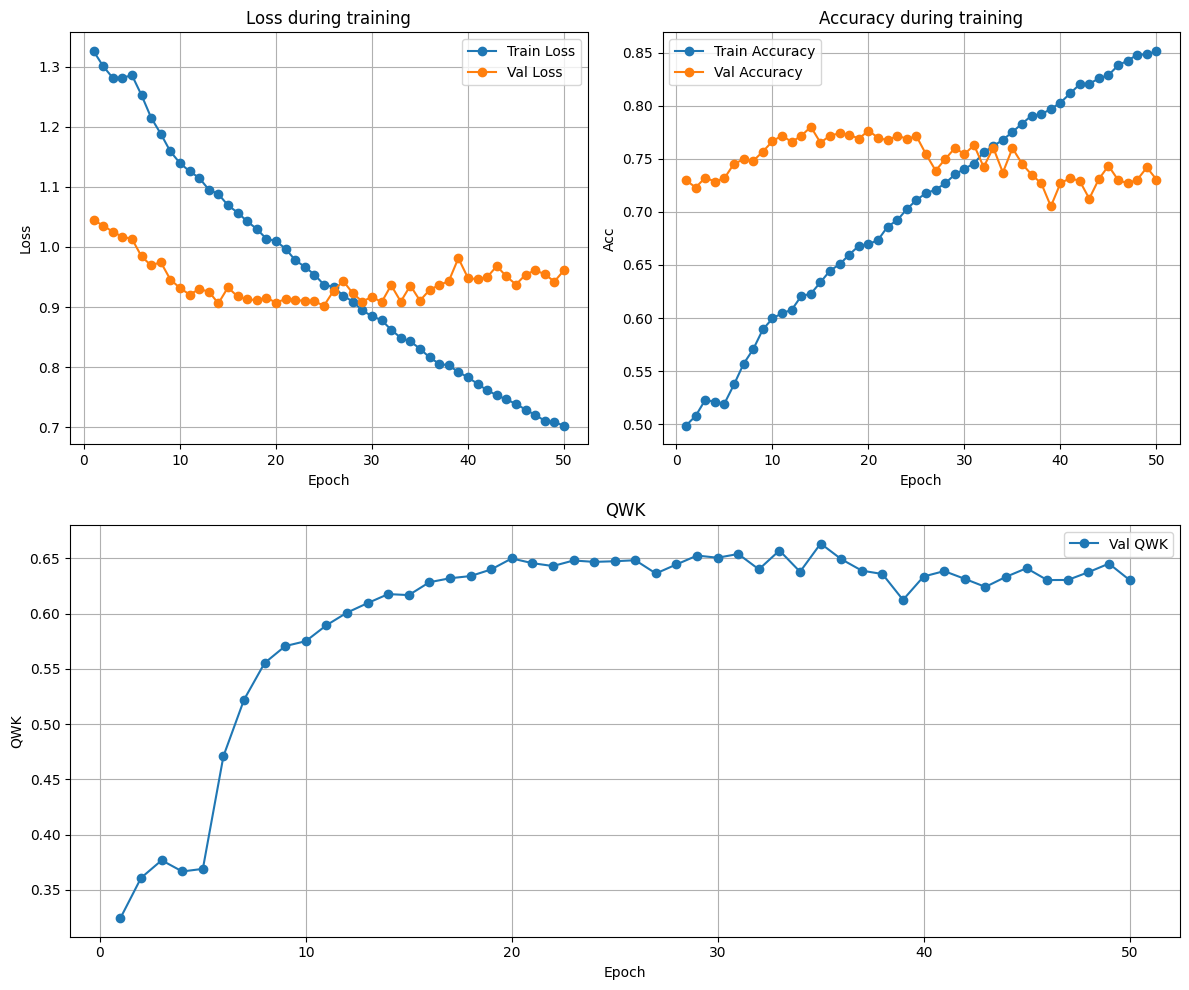

In [8]:
epochs = range(1, len(train_acc_hist) + 1)

plt.figure(figsize=(12,10))

plt.subplot(2,2,1)
plt.plot(epochs, train_loss_hist, label="Train Loss", marker='o')
plt.plot(epochs, val_loss_hist, label="Val Loss", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss during training")
plt.legend()
plt.grid(True)

plt.subplot(2,2,2)
plt.plot(epochs, train_acc_hist, label="Train Accuracy", marker='o')
plt.plot(epochs, val_acc_hist, label="Val Accuracy", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Acc")
plt.title("Accuracy during training")
plt.legend()
plt.grid(True)

plt.subplot(2,1,2)
plt.plot(epochs, qwk_hist, label="Val QWK", marker='o')
plt.xlabel("Epoch")
plt.ylabel("QWK")
plt.title("QWK")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [16]:
model = DRD_EfficientNetB4()
model.load_state_dict(torch.load("../model/retinopathy_best_weights_B4.pth"))
model.to(device)

DRD_EfficientNetB4(
  (backbone): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=48, bias=False)
              (1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(48, 12, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(12, 48, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
            

In [7]:
model.eval()

total_preds = []
total_labels = []

with torch.no_grad():
    for X_batch, y_batch in valloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(X_batch)
        preds = torch.argmax(outputs, 1)

        total_preds.extend(preds.cpu().numpy())
        total_labels.extend(y_batch.cpu().numpy())

In [10]:
cm = confusion_matrix(total_labels, total_preds)
cm

array([[4343,  425,  376,    6,   12],
       [ 319,   94,   72,    3,    1],
       [ 354,   75,  554,   54,   21],
       [  15,    2,   85,   62,   11],
       [  11,    1,   34,   15,   81]])

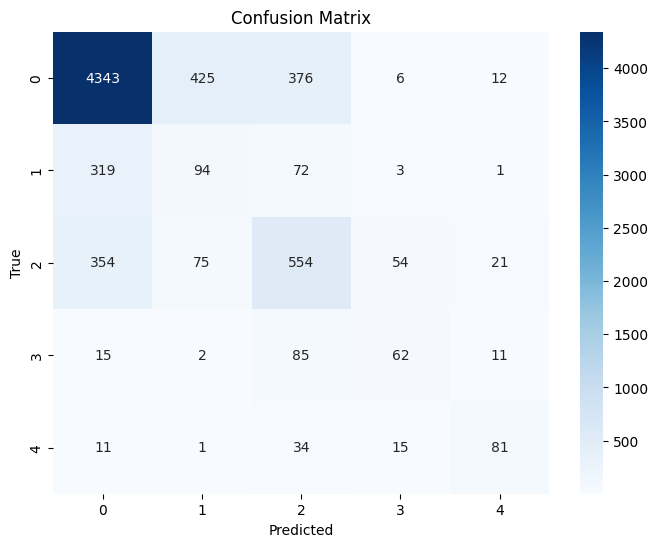

In [11]:
retinopathy = ['0', 
                '1', 
                '2', 
                '3', 
                '4']

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=retinopathy, yticklabels=retinopathy, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()